In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [ ]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [ ]:
x = df.drop(columns=['q_ihfc','ps_z', 'stein_z', 'q_stein'])
y = df['ps_z']

In [ ]:
x.head()

,lat,long,age,q_ps
0,48.7500,-127.75,2.906279,277.518538
1,47.8983,-127.20,4.359262,226.597009
2,47.8983,-127.65,3.190760,264.858297
3,48.6833,-126.87,5.543758,200.936360
4,48.6850,-126.87,5.543758,200.936360


In [ ]:
x.shape

(3691, 4)

In [ ]:
y.head()

0    3096.673436
1    3230.759601
2    3125.194460
3    3324.081515
4    3324.081515
Name: ps_z, dtype: float64

In [ ]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [ ]:
x_train.shape

(2952, 4)

this is the raw validation data

In [ ]:
x_test.shape

(739, 4)

In [ ]:
x_train.describe().round(3)

,lat,long,age,q_ps
count,2952.000,2952.000,2952.000,2952.000
mean,48.169,-128.312,1.779,581.289
std,0.322,0.663,1.650,655.411
min,47.686,-129.505,0.009,182.939
25%,47.881,-128.710,0.592,262.388
50%,48.256,-128.640,0.912,495.320
75%,48.455,-127.785,3.251,615.104
max,48.915,-126.223,6.688,5015.915


In [ ]:
x_test.describe().round(3)

,lat,long,age,q_ps
count,739.000,739.000,739.000,739.000
mean,48.178,-128.330,1.726,558.924
std,0.323,0.636,1.606,567.700
min,47.686,-129.303,0.009,183.864
25%,47.888,-128.710,0.592,264.858
50%,48.360,-128.640,0.867,508.222
75%,48.455,-127.787,3.191,615.104
max,48.997,-126.223,6.621,5015.915


In [ ]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

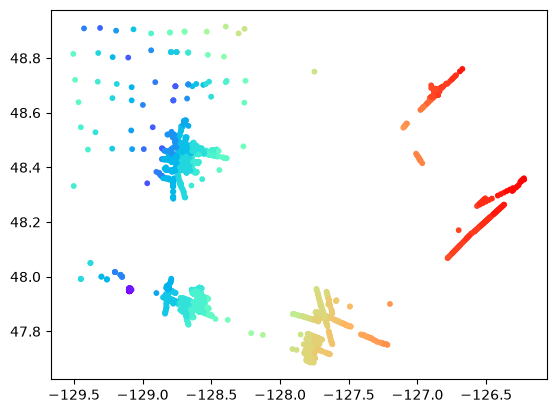

In [ ]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

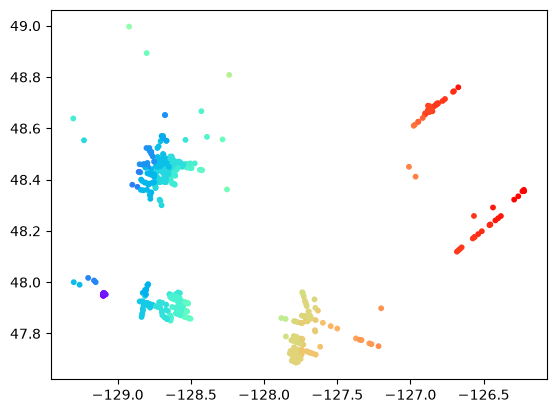

In [ ]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [ ]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [ ]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 2952, number of used features: 4
[LightGBM] [Info] Start training from score 2919.400325


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred.shape

(739,)

In [ ]:
y_pred, y_pred.shape

(array([3210.21518153, 3125.17562791, 2811.7577952 , 2811.7577952 ,
        3131.08066548, 2559.89722732, 2811.7577952 , 2855.84940042,
        3142.64518007, 2769.05734772, 3131.08066548, 3131.06430271,
        3150.34557744, 2560.53745016, 2915.29551942, 2769.21400932,
        2784.97127889, 2811.7577952 , 2811.65837925, 2882.29423814,
        2878.26206883, 2878.25271793, 2734.4751913 , 3339.26990258,
        3131.08066548, 2811.7577952 , 2811.75780794, 2759.96487557,
        2855.83315342, 2878.30718528, 2916.2215629 , 3324.03718215,
        2811.7577952 , 2878.25271793, 2878.23693689, 2758.14166304,
        3352.2087031 , 2878.23436419, 2834.29862206, 2811.7577952 ,
        2811.7577952 , 2769.21400932, 2533.12477708, 3125.2033714 ,
        2811.7577952 , 2908.74734349, 2769.21400932, 2834.28864714,
        2769.21400932, 2916.31571486, 2811.73602551, 2845.5924265 ,
        2916.08759205, 2811.7577952 , 2784.97127889, 2754.98381274,
        3131.08066548, 2754.99096997, 2769.21400

In [ ]:
residuals = y_test - y_pred

negative mean: overpredicting

In [ ]:
residuals.head(), residuals.describe()

(475    -0.621863
 521     0.018832
 1792   -0.008632
 3450   -0.008632
 811     0.000296
 Name: ps_z, dtype: float64,
 count    739.000000
 mean       0.027513
 std        1.166686
 min      -16.698930
 25%       -0.014884
 50%       -0.008632
 75%        0.017799
 max       22.673195
 Name: ps_z, dtype: float64)

In [ ]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [ ]:
pd.DataFrame(dfr).to_csv('..\\created_data\\seg2_ps_z_residuals.csv', index=False)

with open('..\\created_data\\seg2_ps_z_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

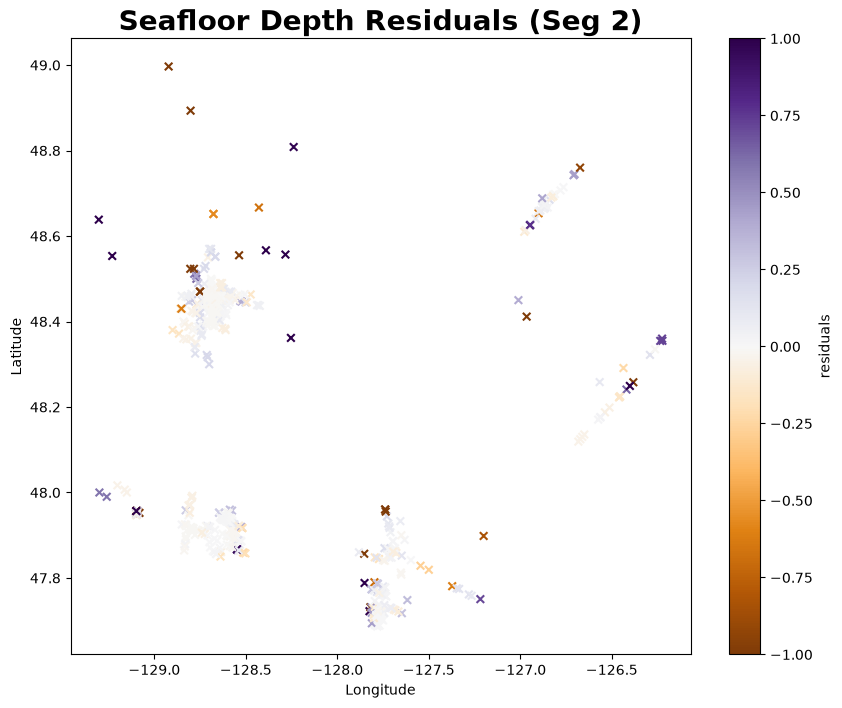

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seafloor Depth Residuals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\res_ps_z_seg2.png', dpi=400)
plt.show()

## now we ... predict!

In [ ]:
de = pd.read_csv('..\\data\\segment3.csv')
de.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,45.0033,-125.303,9.088325,60.0,156.934615,169.171914,3555.139683,3700.359955
1,45.0050,-125.303,9.088325,60.0,156.934615,169.171914,3555.139683,3700.359955
2,45.0033,-125.305,9.088325,102.0,156.934615,169.171914,3555.139683,3700.359955
3,45.0000,-125.321,9.088325,84.0,156.934615,169.171914,3555.139683,3700.359955
4,47.0633,-125.890,7.629121,100.0,171.286610,184.643035,3466.730210,3608.161504


In [ ]:
xe = de.drop(columns=['q_ihfc','ps_z', 'stein_z', 'q_stein'])
ye = de['ps_z']

In [ ]:
sp = 250
grid_long = np.linspace(xe['long'].min(), xe['long'].max(), sp)
grid_lat = np.linspace(xe['lat'].min(), xe['lat'].max(), sp)

In [ ]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [ ]:
long.shape, lat.shape

((100, 100), (100, 100))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [ ]:
age_interp = griddata((de['long'], de['lat']), de['age'], (long, lat), method='linear')
hf_interp  = griddata((de['long'], de['lat']), de['q_ps'], (long, lat), method='linear')

In [ ]:
age_interp.shape, hf_interp.shape

((100, 100), (100, 100))

np.vstack stacks arrays as new rows

In [ ]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel()]).T

In [ ]:
lola.shape

(10000, 4)

ensure nans are just around the edges

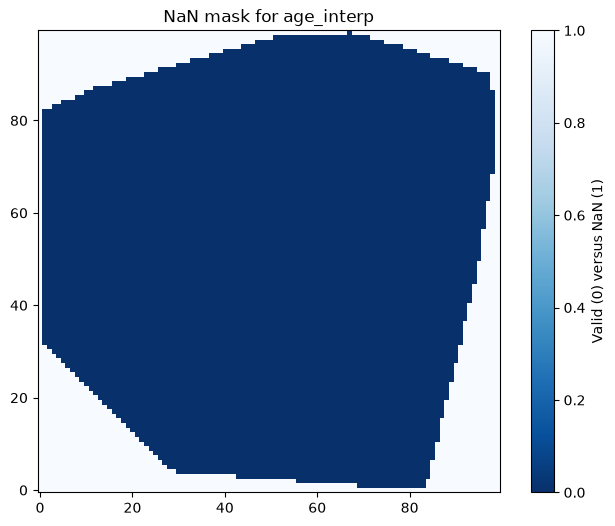

In [ ]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r')
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [ ]:
lola_pred = model.predict(lola)

In [ ]:
lola_pred[0:5]

array([2891.57597506, 2891.57597506, 2891.57597506, 2891.57597506,
       2891.57597506])

In [ ]:
lola_pred = lola_pred.reshape(long.shape)

In [ ]:
lola_pred.shape

(100, 100)

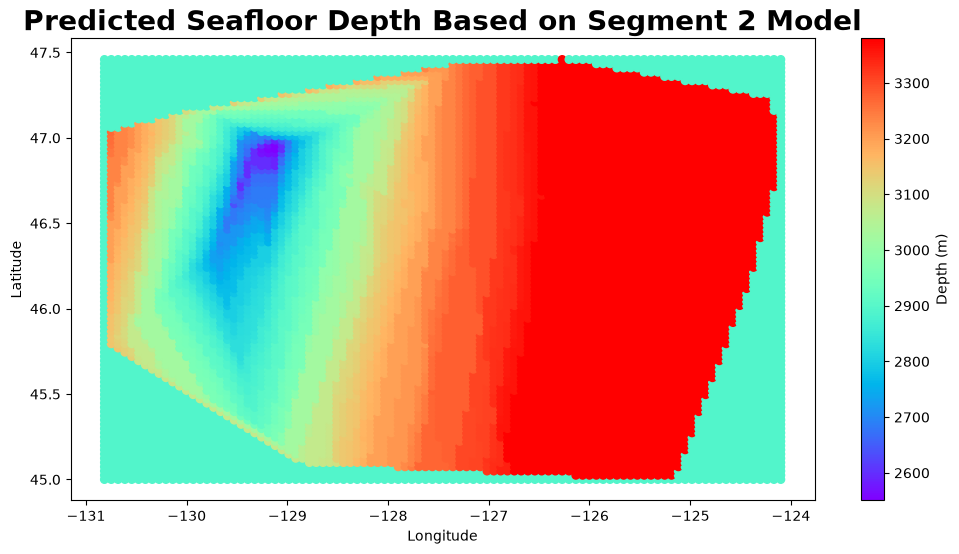

In [208]:
plt.figure(figsize=(12, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Seafloor Depth Based on Segment 2 Model', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig(f'..\\figs\\xval_seg3_ps_z_pred_{sp}.png', dpi=400)
plt.show()